# Rail Corrugation
## Signal Analysis

This notebook investigates how the vibration characteristics differ between Normal, Side I and Side II recordings.

Objectives:
- Test whether RMS differences observed during EDA generalise across the dataset
- Compare Side I and Side II vibration behaviour
- Examine frequency-domain characteristics
- Identify potential signal features for classification

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.signal import welch

DATA_DIR = Path("..")
TRAIN_PATH = DATA_DIR / "Train"
LABELS_PATH = DATA_DIR / "Train_Labels.csv"

labels = pd.read_csv(LABELS_PATH)

sample = pd.read_csv(TRAIN_PATH / "Train1.csv")

vib_cols = [c for c in sample.columns if "vibration" in c.lower()]
shock_cols = [c for c in sample.columns if "shock" in c.lower()]

side1_vib = [c for c in vib_cols if any(f"position {p}" in c.lower() for p in [1, 3, 5, 7])]
side2_vib = [c for c in vib_cols if any(f"position {p}" in c.lower() for p in [2, 4, 6, 8])]

train1 = pd.read_csv(TRAIN_PATH / "Train1.csv")
train2 = pd.read_csv(TRAIN_PATH / "Train2.csv")
train62 = pd.read_csv(TRAIN_PATH / "Train62.csv")

In [3]:
def rms(data):
    return np.sqrt(np.mean(data ** 2))

rows = []

for _, row in labels.iterrows():
    data = pd.read_csv(TRAIN_PATH / row["filename"])

    rows.append({
        "filename": row["filename"],
        "label": row["label"],
        "vib_rms": rms(data[vib_cols].values),
        "side1_rms": rms(data[side1_vib].values),
        "side2_rms": rms(data[side2_vib].values)
    })

features = pd.DataFrame(rows)

In [4]:
display(features.head())

,filename,label,vib_rms,side1_rms,side2_rms
0,Train1.csv,Normal,0.188176,0.196928,0.178996
1,Train2.csv,Side II,0.943912,0.916845,0.970224
2,Train3.csv,Normal,0.497476,0.489453,0.505371
3,Train4.csv,Normal,0.479603,0.417142,0.534819
4,Train5.csv,Normal,0.068899,0.076755,0.060023


In [5]:
display(features.groupby("label")[["vib_rms", "side1_rms", "side2_rms"]].describe())

vib_rms                                                              \
          count      mean       std       min       25%       50%       75%   
label                                                                         
Normal    234.0  0.304794  0.186772  0.067787  0.153124  0.282731  0.449065   
Side I     14.0  0.580474  0.147182  0.344396  0.503391  0.568529  0.631295   
Side II    24.0  0.727706  0.167712  0.427581  0.598427  0.726415  0.853194   

                  side1_rms            ...                     side2_rms  \
              max     count      mean  ...       75%       max     count   
label                                  ...                                 
Normal   0.830903     234.0  0.303036  ...  0.435607  0.843463     234.0   
Side I   0.866406      14.0  0.616152  ...  0.662294  0.951724      14.0   
Side II  0.973005      24.0  0.635046  ...  0.759734  0.918533      24.0   

                                                                               
             mean       std       min       25%       50%       75%       max  
label                                                                          
Normal   0.305121  0.193700  0.058319  0.156488  0.286440  0.460430  0.848024  
Side I   0.536200  0.175034  0.278877  0.430125  0.550988  0.632907  0.843524  
Side II  0.803052  0.172010  0.369484  0.693366  0.814541  0.952405  1.028216  

[3 rows x 24 columns]

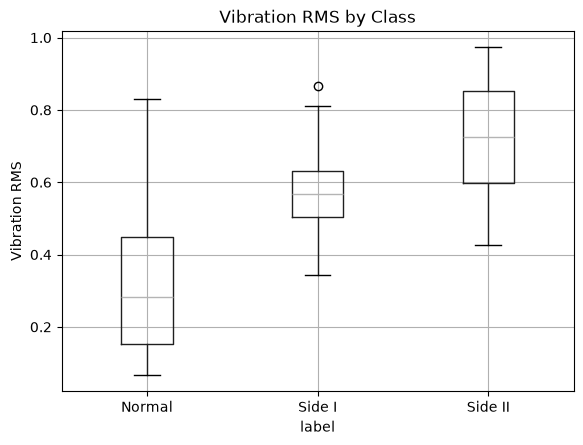

In [6]:
features.boxplot(column="vib_rms", by="label")

plt.ylabel("Vibration RMS")
plt.title("Vibration RMS by Class")
plt.suptitle("")
plt.show()

## Side I vs Side II

A useful classifier should not only detect abnormal vibration but also determine which rail side is affected.

We therefore compare the RMS measured on both sides.

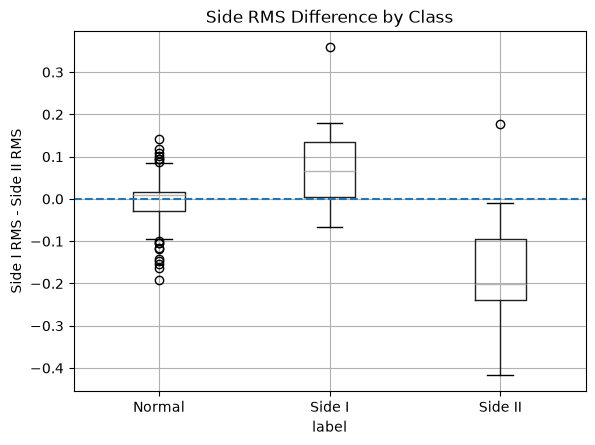

In [7]:
features["side_diff"] = features["side1_rms"] - features["side2_rms"]
features["side_ratio"] = features["side1_rms"] / features["side2_rms"]

features.boxplot(column="side_diff", by="label")

plt.axhline(0, linestyle="--")
plt.ylabel("Side I RMS - Side II RMS")
plt.title("Side RMS Difference by Class")
plt.suptitle("")
plt.show()

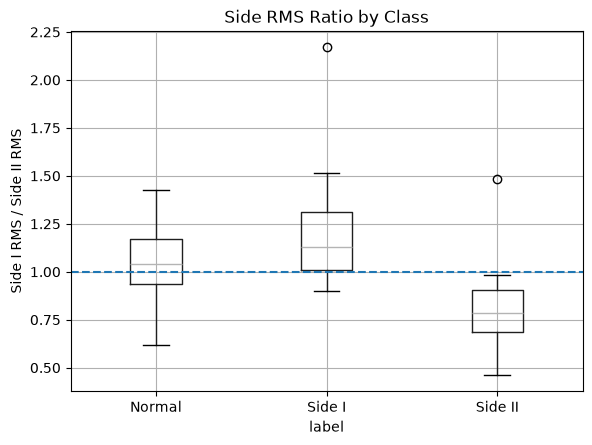

In [8]:
features.boxplot(column="side_ratio", by="label")

plt.axhline(1, linestyle="--")
plt.ylabel("Side I RMS / Side II RMS")
plt.title("Side RMS Ratio by Class")
plt.suptitle("")
plt.show()

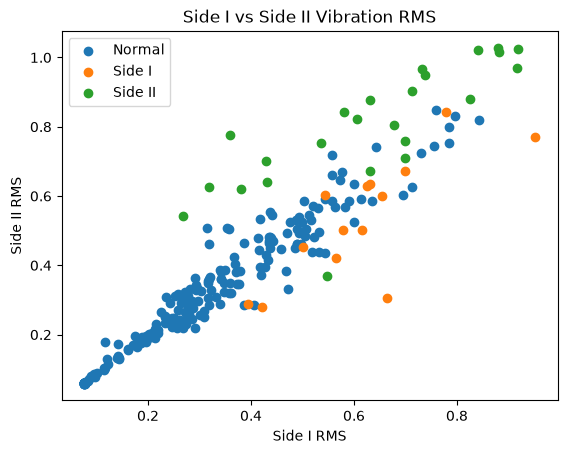

In [9]:
for label in ["Normal", "Side I", "Side II"]:
    subset = features[features["label"] == label]

    plt.scatter(subset["side1_rms"], subset["side2_rms"], label=label)

plt.xlabel("Side I RMS")
plt.ylabel("Side II RMS")
plt.legend()
plt.title("Side I vs Side II Vibration RMS")
plt.show()

## Frequency-Domain Analysis

Rail corrugation produces periodic wheel-rail excitation.

We therefore examine the frequency spectrum of representative vibration signals to determine whether the classes contain different spectral characteristics.

In [13]:
FS = 10000

signal = train1[vib_cols[0]].values

freq = np.fft.rfftfreq(len(signal), 1 / FS)
fft = np.abs(np.fft.rfft(signal))

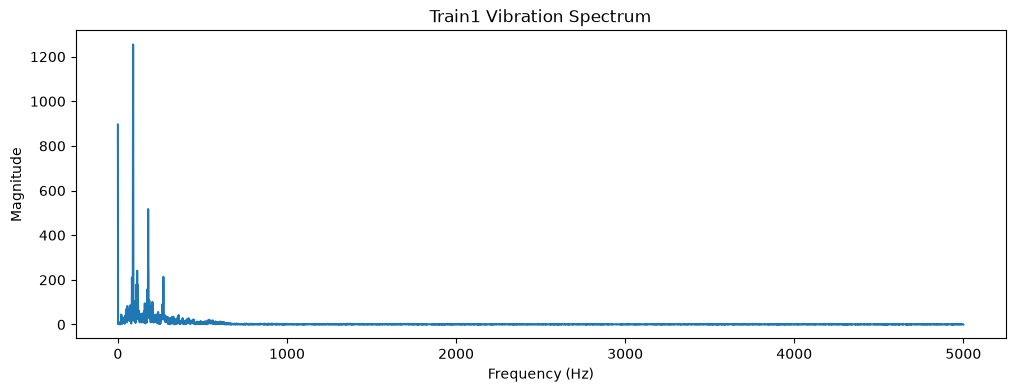

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(freq, fft)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("Train1 Vibration Spectrum")
plt.show()

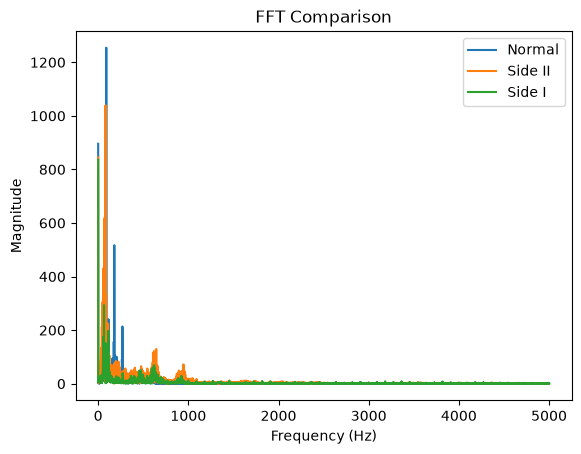

In [15]:
samples = {
    "Normal": train1,
    "Side II": train2,
    "Side I": train62
}

for name, data in samples.items():
    fft = np.abs(np.fft.rfft(data[vib_cols[0]].values))
    plt.plot(freq, fft, label=name)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.title("FFT Comparison")
plt.show()

## Power Spectral Density

Welch's method provides a smoother estimate of how signal power is distributed across frequency.

This can make characteristic corrugation frequency bands easier to identify than the raw FFT.

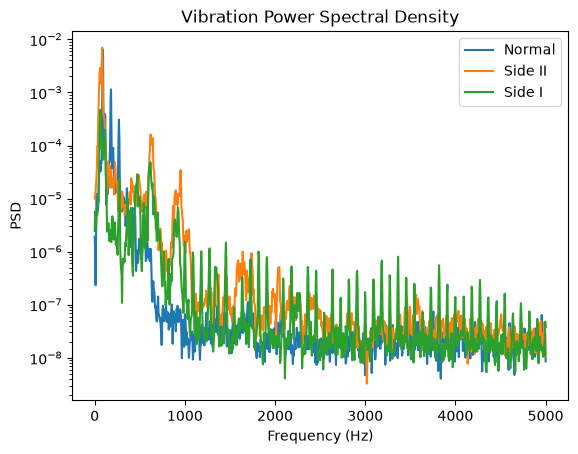

In [17]:
for name, data in samples.items():
    signal = data[vib_cols[0]].to_numpy()
    f, psd = welch(signal, fs=FS, nperseg=2048)
    plt.semilogy(f, psd, label=name)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.legend()
plt.title("Vibration Power Spectral Density")
plt.show()

## Side-Specific Spectral Analysis

Instead of analysing a single arbitrary axle box, compare sensors belonging to the rail side associated with each fault.

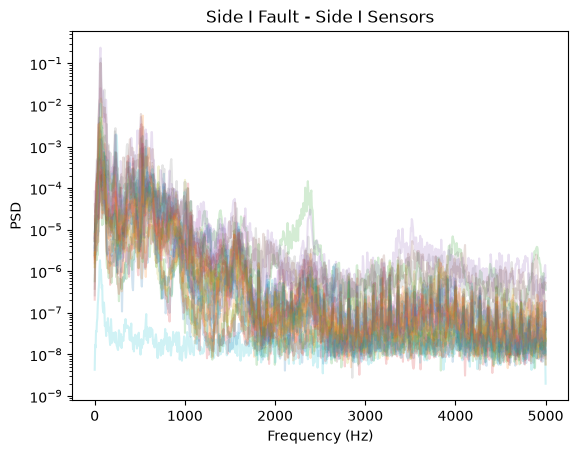

In [19]:
for col in side1_vib:
    signal = train62[col].to_numpy()
    f, psd = welch(signal, fs=FS, nperseg=2048)
    plt.semilogy(f, psd, alpha=0.2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Side I Fault - Side I Sensors")
plt.show()

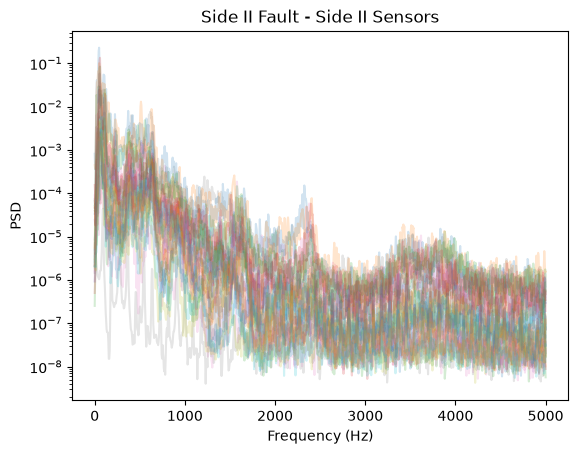

In [20]:
for col in side2_vib:
    signal = train2[col].to_numpy()
    f, psd = welch(signal, fs=FS, nperseg=2048)
    plt.semilogy(f, psd, alpha=0.2)

plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Side II Fault - Side II Sensors")
plt.show()

## Average Power Spectral Density

Individual axle-box signals can contain noise and local variations.

We therefore calculate the mean PSD across all sensors belonging to each rail side.

In [23]:
def mean_psd(data, columns):
    psds = [welch(data[col].to_numpy(), fs=FS, nperseg=2048)[1] for col in columns]
    return np.mean(psds, axis=0)

f, _ = welch(train1[vib_cols[0]].to_numpy(), fs=FS, nperseg=2048)

normal_side1 = mean_psd(train1, side1_vib)
normal_side2 = mean_psd(train1, side2_vib)

side1_fault = mean_psd(train62, side1_vib)
side2_fault = mean_psd(train2, side2_vib)

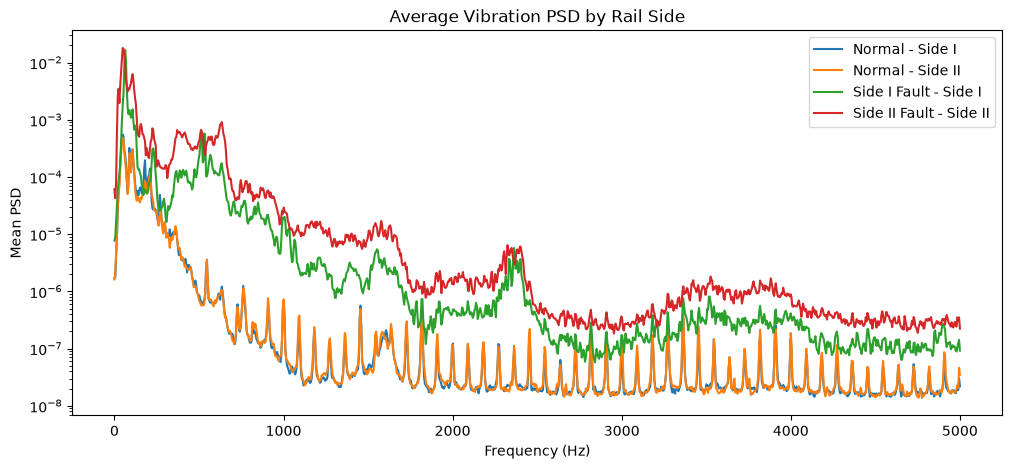

In [24]:
plt.figure(figsize=(12, 5))

plt.semilogy(f, normal_side1, label="Normal - Side I")
plt.semilogy(f, normal_side2, label="Normal - Side II")
plt.semilogy(f, side1_fault, label="Side I Fault - Side I")
plt.semilogy(f, side2_fault, label="Side II Fault - Side II")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean PSD")
plt.title("Average Vibration PSD by Rail Side")
plt.legend()
plt.show()

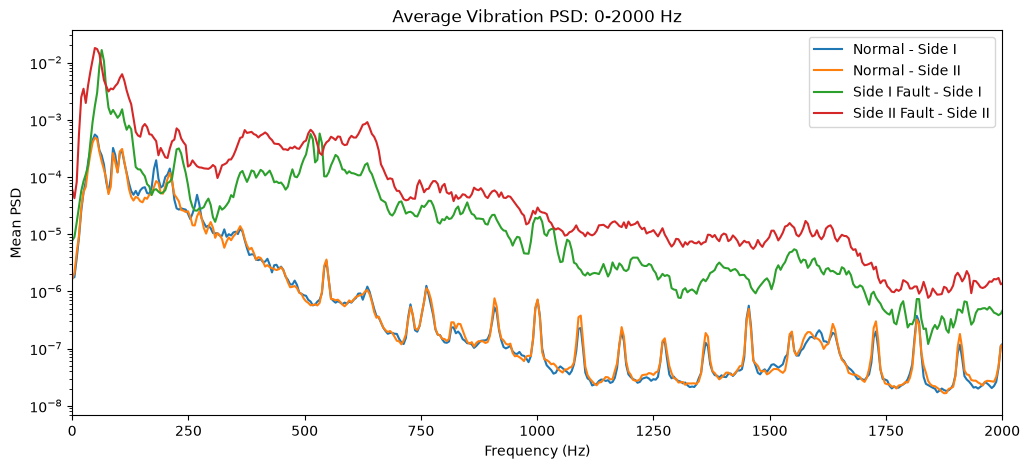

In [25]:
plt.figure(figsize=(12, 5))

plt.semilogy(f, normal_side1, label="Normal - Side I")
plt.semilogy(f, normal_side2, label="Normal - Side II")
plt.semilogy(f, side1_fault, label="Side I Fault - Side I")
plt.semilogy(f, side2_fault, label="Side II Fault - Side II")

plt.xlim(0, 2000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Mean PSD")
plt.title("Average Vibration PSD: 0-2000 Hz")
plt.legend()
plt.show()

## Dominant Frequency

We identify the frequency containing the maximum PSD value for each recording.

This provides a simple way to compare whether the fault recordings contain characteristic frequency peaks.

In [27]:
def dominant_frequency(signal):
    f, psd = welch(signal, fs=FS, nperseg=2048)
    return f[np.argmax(psd)]

for name, data in samples.items():
    freq_peak = dominant_frequency(data[vib_cols[0]].to_numpy())
    print(name, ":", round(freq_peak, 2), "Hz")

Normal : 87.89 Hz
Side II : 83.01 Hz
Side I : 63.48 Hz
